In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

In [2]:
df_original=pd.read_csv("coffee_shop_ales.csv")   
df = df_original.sample(n=50000, random_state=42)


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 50000 entries, 116605 to 16924
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    50000 non-null  int64  
 1   transaction_date  50000 non-null  str    
 2   transaction_time  50000 non-null  str    
 3   transaction_qty   50000 non-null  int64  
 4   store_id          50000 non-null  int64  
 5   store_location    50000 non-null  str    
 6   product_id        50000 non-null  int64  
 7   unit_price        50000 non-null  float64
 8   product_category  50000 non-null  str    
 9   product_type      50000 non-null  str    
 10  product_detail    50000 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 4.6 MB


In [4]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
116605,116867,6/3/23,14:04:38,2,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte
119259,119521,6/5/23,17:41:39,1,5,Lower Manhattan,79,3.75,Bakery,Scone,Jumbo Savory Scone
105265,105519,5/23/23,16:56:17,3,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
29485,29542,2/21/23,15:40:56,3,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte
126885,127222,6/12/23,9:23:04,1,8,Hell's Kitchen,36,3.75,Coffee,Premium brewed coffee,Jamaican Coffee River Lg


In [6]:
# constant values
TARGET_COL = "unit_price"
BATCH_SIZE = 64
EPOCHS = 50
ALPHA=0.001

# Data preprocessing


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Splitting
x = df.drop(columns=[TARGET_COL]) # Features
y = df[TARGET_COL] # Target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Encoding categorical features using LabelEncoder
def encode_train(df):
    df = df.copy()
    encoders = {}
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(str)
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
            encoders[col] = encoder
    return df, encoders

def encode_test(df, encoders):
    df = df.copy()
    for col, encoder in encoders.items():
        df[col] = df[col].astype(str)
        known = set(encoder.classes_)
        df[col] = df[col].apply(lambda x: encoder.transform([x])[0] if x in known else -1)
    return df

encoded_xtrain, encoders = encode_train(x_train)   # train
encoded_xtest = encode_test(x_test, encoders)  # test


# Pandas to Numpy
x_train = encoded_xtrain.to_numpy()
x_test = encoded_xtest.to_numpy()
y_train_arr = y_train.to_numpy().reshape(-1, 1)
y_test_arr = y_test.to_numpy().reshape(-1, 1)

# Scaling for features
x_scaler = MinMaxScaler()
scaled_xtrain = x_scaler.fit_transform(encoded_xtrain)
scaled_xtest  = x_scaler.transform(encoded_xtest)

# Scaling for target
y_scaler = MinMaxScaler()
scaled_ytrain = y_scaler.fit_transform(y_train_arr)
scaled_ytest  = y_scaler.transform(y_test_arr)

# Numpy to Torch Tensor
x_train_tensor = torch.tensor(scaled_xtrain, dtype=torch.float32)
x_test_tensor = torch.tensor(scaled_xtest, dtype=torch.float32)
y_train_tensor = torch.tensor(scaled_ytrain, dtype=torch.float32)
y_test_tensor = torch.tensor(scaled_ytest, dtype=torch.float32)

In [8]:
print("X Train Tensor:", x_train_tensor)
print("Y Train Tensor:", y_train_tensor)
print("X Test Tensor:", x_test_tensor)
print("Y Test Tensor:", y_test_tensor)

X Train Tensor: tensor([[0.2524, 0.4833, 0.7136,  ..., 0.2500, 0.4643, 0.4177],
        [0.4868, 0.5722, 0.4137,  ..., 0.6250, 0.9286, 0.1392],
        [0.2299, 0.3278, 0.6259,  ..., 0.2500, 0.7857, 0.0253],
        ...,
        [0.2367, 0.4500, 0.3066,  ..., 1.0000, 0.1429, 0.8987],
        [0.8686, 0.8667, 0.0086,  ..., 0.3750, 0.5000, 0.4557],
        [0.4545, 0.5389, 0.8806,  ..., 0.0000, 0.0357, 0.4304]])
Y Train Tensor: tensor([[0.0317],
        [0.0000],
        [0.0611],
        ...,
        [0.0520],
        [0.2081],
        [0.0611]])
X Test Tensor: tensor([[0.2848, 0.3500, 0.5063,  ..., 1.0000, 0.1071, 0.2911],
        [0.9126, 0.8944, 0.2483,  ..., 0.0000, 0.0357, 0.1139],
        [0.2963, 0.3667, 0.8684,  ..., 0.6250, 0.9286, 0.0886],
        ...,
        [0.8059, 0.9833, 0.4606,  ..., 0.2500, 0.3571, 0.7342],
        [0.8690, 0.8667, 0.0318,  ..., 0.1250, 0.2857, 0.5190],
        [0.2671, 0.3333, 0.7826,  ..., 1.0000, 0.1071, 0.3038]])
Y Test Tensor: tensor([[0.0498],
  

# Functions

In [11]:
def make_loaders(x_train, y_train, batch_size):
    train_ds = TensorDataset(x_train, y_train)

    train_size = int(0.9 * len(train_ds))
    val_size = len(train_ds) - train_size

    train_dataset, val_dataset = random_split(
        train_ds,
        [train_size, val_size]
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0

    for bx, by in loader:
        pred = model(bx)
        loss = loss_fn(pred, by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * bx.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def val_one_epoch(model, loader, loss_fn):
    model.eval()
    total_val_loss = 0

    for bx, by in loader:
        pred = model(bx)
        loss = loss_fn(pred, by)

        total_val_loss += loss.item() * bx.size(0)

    return total_val_loss / len(loader.dataset)

def fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs, early_stop_patience=None):

    train_losses, val_losses = [], []
    best_val = float("inf")
    patience_left = early_stop_patience

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss = val_one_epoch(model, val_loader, loss_fn)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | train={tr_loss:.8f} | val={val_loss:.8f}")

        # Early stopping
        if early_stop_patience is not None:
            if val_loss < best_val:
                best_val = val_loss
                patience_left = early_stop_patience
            else: 
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stop at epoch {epoch} (best val={best_val:.4f})")
                    break

    return train_losses, val_losses


def plot_losses(train_losses, val_losses, title="Loss Curves"):
    plt.figure()
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


# Training

Epoch 001 | train=0.00254382 | val=0.00098301
Epoch 010 | train=0.00016390 | val=0.00013944
Epoch 020 | train=0.00008582 | val=0.00005973
Epoch 030 | train=0.00006402 | val=0.00003642
Epoch 040 | train=0.00006070 | val=0.00004304
Epoch 050 | train=0.00003471 | val=0.00002740


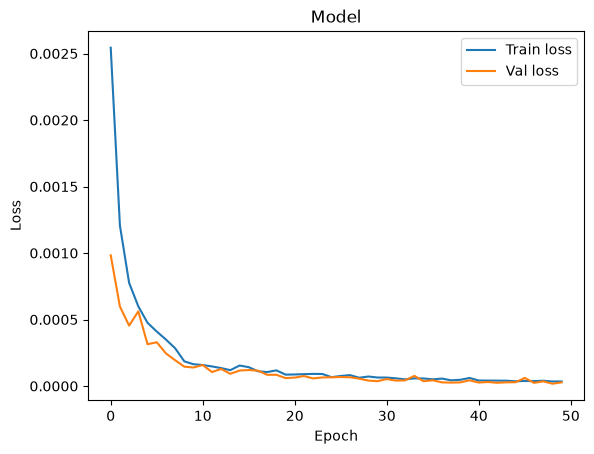

In [12]:
input_dim = x_train_tensor.shape[1] # features
hidden_dim = 256 # hidden units
output_dim = 1 # output units


train_loader, val_loader = make_loaders(x_train_tensor, y_train_tensor, batch_size=BATCH_SIZE)

model = nn.Sequential(  
    nn.Linear(input_dim, hidden_dim), 
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim), 
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=ALPHA)


train_losses, val_losses = fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs=EPOCHS)
plot_losses(train_losses, val_losses, title="Model")


In [ ]:
# Chizmadak korishimiz mumkinki overfitting ham underfitting ham ro'y bermayabdi.
# Overfitting => train - low, val - high
# Underfitting => train - high, val - high
# chizmada train - low, val - low train=0.00003471 | val=0.00002740
# Shu sababli model yaxshi o'rganyabdi deyishimiz mumkin.
# R2 ni teksahirib ko'ramiz.

# Evaluation

In [13]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test_tensor.numpy(), model(x_test_tensor).detach().numpy())
print("R²:", r2)

R²: 0.9879699349403381
